In [333]:
import os
import pandas as pd
import numpy as np
import itertools
from snakemake.io import expand
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib.gridspec import GridSpec

os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')
sns.set_style('white')

In [334]:
# reading in the data from truvari json reports

def create_labels(coverage, svtype, upper, lower = None):
    labels = []
    if lower == None:
        for cov, sv, upper_svlen in itertools.product(coverage, svtype, upper):
            labels.append([cov, sv, upper_svlen])
    else:
        for bin_range in zip(lower, upper):
            for cov, sv in itertools.product(coverage, svtype):
                    labels.append([cov, sv, bin_range])
    # always in the order of coverage, svtype, upper OR coverage, svtype, bin_range
    return labels

def combine_cumulative_json(base_path, labels, return_full = False):
    json_paths = [base_path.format(coverage = '{cov}X'.format(cov = label[0]), svtype = label[1], upper = label[2]) for label in labels]
    temp = []
    for path, label in zip(json_paths, labels):
            report = pd.read_json(path).loc['size']
            labels = pd.Series(label, index = ['coverage', 'svtype', 'upper_svlen'])
            temp.append(pd.concat([report, labels]))
    if return_full:
        return pd.DataFrame(temp).set_index(['coverage', 'svtype', 'upper_svlen'])
    else:
        return pd.DataFrame(temp).set_index(['coverage', 'svtype', 'upper_svlen'])[['precision', 'recall']]

def combine_bins_json(base_path, labels, return_full = False):
    json_paths = [base_path.format(coverage = '{cov}X'.format(cov = label[0]), svtype = label[1], lower = label[2][0], upper = label[2][1]) for label in labels]
    temp = []

    for path, label in zip(json_paths, labels):
            report = pd.read_json(path).loc['size']
            labels = pd.Series(label, index = ['coverage', 'svtype', 'bin_range'])
            temp.append(pd.concat([report, labels]))
    if return_full:
        bindf = pd.DataFrame(temp)
        bindf['bin_range'] = bindf['bin_range'].astype('str').str.replace('()', '', regex = True).astype('category')
        return bindf.set_index(['coverage', 'svtype', 'bin_range'])
    else:
        bindf = pd.DataFrame(temp)
        bindf['bin_range'] = bindf['bin_range'].astype('str').str.replace('()', '', regex = True).astype('category')
        return bindf.set_index(['coverage', 'svtype', 'bin_range'])[['precision', 'recall']]


# Simulation

In [335]:
cumulative_labels = create_labels(coverage = [1, 2, 3, 4, 5, 7, 10], svtype = ['INS', 'DEL'], upper = [100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000])
cumulative_df = combine_cumulative_json('output/mapping/hg38/simulations/spike_in/{coverage}/truvari/{svtype}/cumulative/{upper}/summary.json', cumulative_labels, return_full = True)
cumulative_df.sort_index(inplace=True)
cumulative_df.head()

TP-base  TP-comp   FP    FN  precision    recall  \
coverage svtype upper_svlen                                                     
1        DEL    100              265      265  366  1864   0.419968  0.124472   
                250              418      418  603  2798   0.409403  0.129975   
                500              551      551  709  3974   0.437302  0.121768   
                750              569      569  773  4102   0.423994  0.121815   
                1000             585      585  785  4203   0.427007  0.122180   

                                   f1  base cnt  comp cnt  TP-comp_TP-gt  \
coverage svtype upper_svlen                                                
1        DEL    100          0.192029      2129       631              0   
                250          0.197309      3216      1021              0   
                500          0.190493      4525      1260              0   
                750          0.189257      4671      1342              0   
                1000         0.189997      4788      1370              0   

                             TP-comp_FP-gt  TP-base_TP-gt  TP-base_FP-gt  \
coverage svtype upper_svlen                                                
1        DEL    100                    265              0            265   
                250                    418              0            418   
                500                    551              0            551   
                750                    569              0            569   
                1000                   585              0            585   

                             gt_concordance  gt_matrix  \
coverage svtype upper_svlen                              
1        DEL    100                     0.0        NaN   
                250                     0.0        NaN   
                500                     0.0        NaN   
                750                     0.0        NaN   
                1000                    0.0        NaN   

                                                                      weighted  
coverage svtype upper_svlen                                                     
1        DEL    100          {'TP': 267.50319999456406, 'FP': 363.496800005...  
                250          {'TP': 423.74279990792274, 'FP': 597.257200092...  
                500          {'TP': 560.1264001280069, 'FP': 699.8735998719...  
                750          {'TP': 578.8380001336336, 'FP': 763.1619998663...  
                1000         {'TP': 594.7494001090527, 'FP': 775.2505998909...

In [336]:
bins_labels = create_labels(coverage = [1, 2, 3, 4, 5, 7, 10], svtype = ['INS', 'DEL'], lower = [100, 250, 500, 750, 1000, 2500, 5000, 7500], upper = [250, 500, 750, 1000, 2500, 5000, 7500, 10000])
bins_df = combine_bins_json('output/mapping/hg38/simulations/spike_in/{coverage}/truvari/{svtype}/bins/{lower}_{upper}/summary.json', bins_labels, return_full = True)
bins_df.sort_index(inplace=True)
bins_df.head()

TP-base  TP-comp   FP    FN  precision  \
coverage svtype bin_range                                              
1        DEL    (100, 250)        151      151  247   959   0.379397   
                (1000, 2500)       36       36   37   259   0.493151   
                (250, 500)        132      132  111  1182   0.543210   
                (2500, 5000)       13       13    8   143   0.619048   
                (500, 750)         18       18   65   128   0.216867   

                                recall        f1  base cnt  comp cnt  \
coverage svtype bin_range                                              
1        DEL    (100, 250)    0.136036  0.200265      1110       398   
                (1000, 2500)  0.122034  0.195652       295        73   
                (250, 500)    0.100457  0.169557      1314       243   
                (2500, 5000)  0.083333  0.146893       156        21   
                (500, 750)    0.123288  0.157205       146        83   

                              TP-comp_TP-gt  TP-comp_FP-gt  TP-base_TP-gt  \
coverage svtype bin_range                                                   
1        DEL    (100, 250)                0            151              0   
                (1000, 2500)              0             36              0   
                (250, 500)                0            132              0   
                (2500, 5000)              0             13              0   
                (500, 750)                0             18              0   

                              TP-base_FP-gt  gt_concordance  gt_matrix  \
coverage svtype bin_range                                                
1        DEL    (100, 250)              151             0.0        NaN   
                (1000, 2500)             36             0.0        NaN   
                (250, 500)              132             0.0        NaN   
                (2500, 5000)             13             0.0        NaN   
                (500, 750)               18             0.0        NaN   

                                                                       weighted  
coverage svtype bin_range                                                        
1        DEL    (100, 250)    {'TP': 149.49590003490448, 'FP': 248.504099965...  
                (1000, 2500)  {'TP': 36.43410009145737, 'FP': 36.56589990854...  
                (250, 500)    {'TP': 131.9161001443863, 'FP': 111.0838998556...  
                (2500, 5000)  {'TP': 12.995800077915192, 'FP': 8.00419992208...  
                (500, 750)    {'TP': 17.976599991321564, 'FP': 65.0234000086...

## Insertions

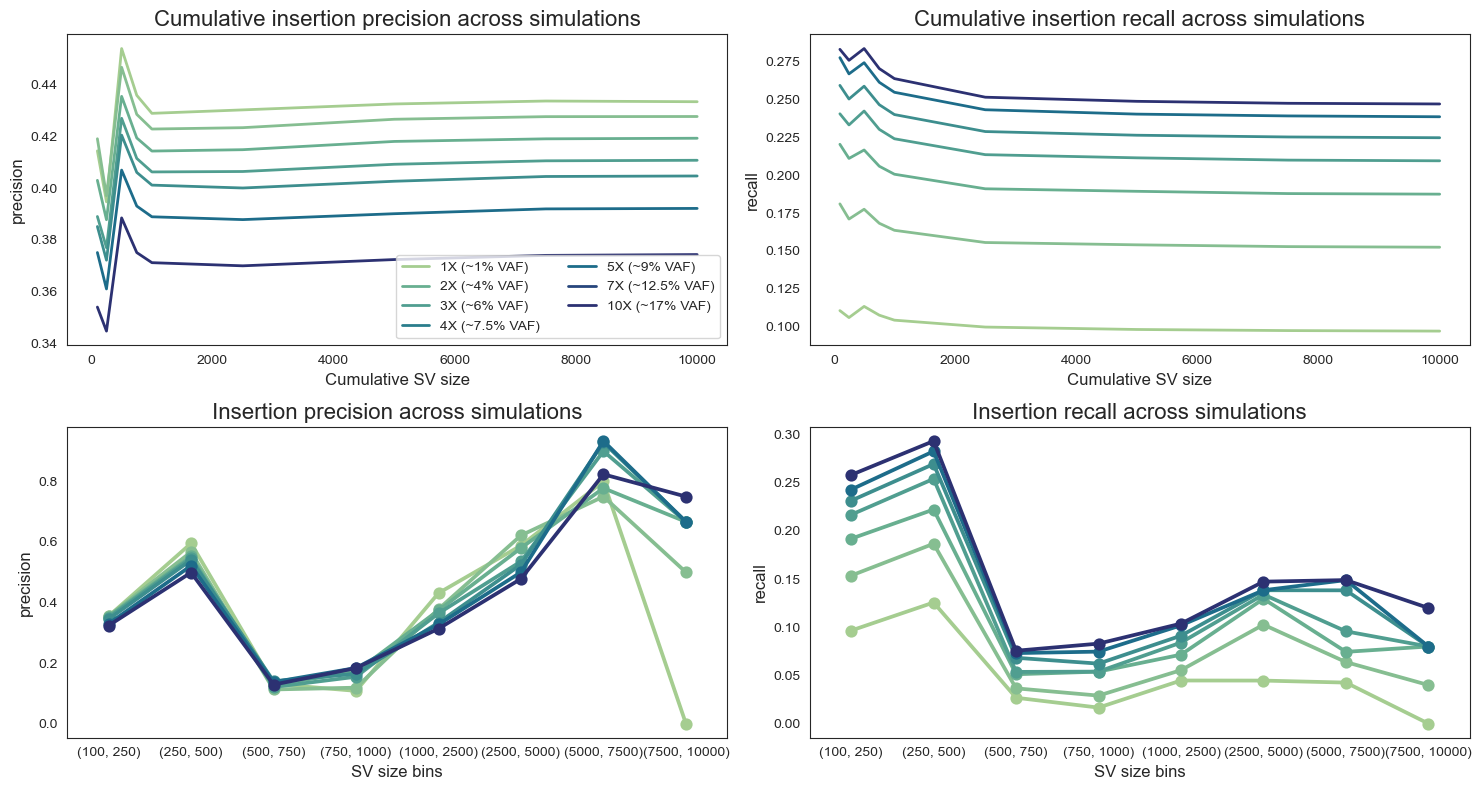

In [463]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for index, t_ax, svtype, info in zip([0, 1], axes.flatten()[:2], ['INS', 'INS'], ['precision', 'recall']):
    sns.lineplot(cumulative_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = t_ax, x = 'upper_svlen', y = info, hue = 'coverage',
                     palette = sns.color_palette("crest", as_cmap = True), linewidth = 2)
    t_ax.set_title("Cumulative insertion {info} across simulations".format(info = info), size = 16)
    t_ax.set_ylabel(info, size = 12)
    t_ax.set_xlabel('Cumulative SV size', size = 12)

    # fixes mis-labeled coverage labels: not sure why that happens, it's weird
    h, l = t_ax.get_legend_handles_labels()
    t_ax.legend(handles = h, labels = ['1X (~1% VAF)', '2X (~4% VAF)', '3X (~6% VAF)', '4X (~7.5% VAF)', '5X (~9% VAF)', '7X (~12.5% VAF)', '10X (~17% VAF)'], ncols = 2, loc = 'lower right')

    if index != 0:
        t_ax.get_legend().remove()

for b_ax, svtype, info in zip(axes.flatten()[2:], ['INS', 'INS'], ['precision', 'recall']):
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("crest", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      legend = None)
    b_ax.set_title("Insertion {info} across simulations".format(info = info), size = 16)
    b_ax.set_ylabel(info, size = 12)
    b_ax.set_xlabel('SV size bins', size = 12)

# for i, ax in enumerate(axes.flatten()):
#     if i not in [0, 1]:
#         ax.legend_ = None

plt.tight_layout()

## Deletions

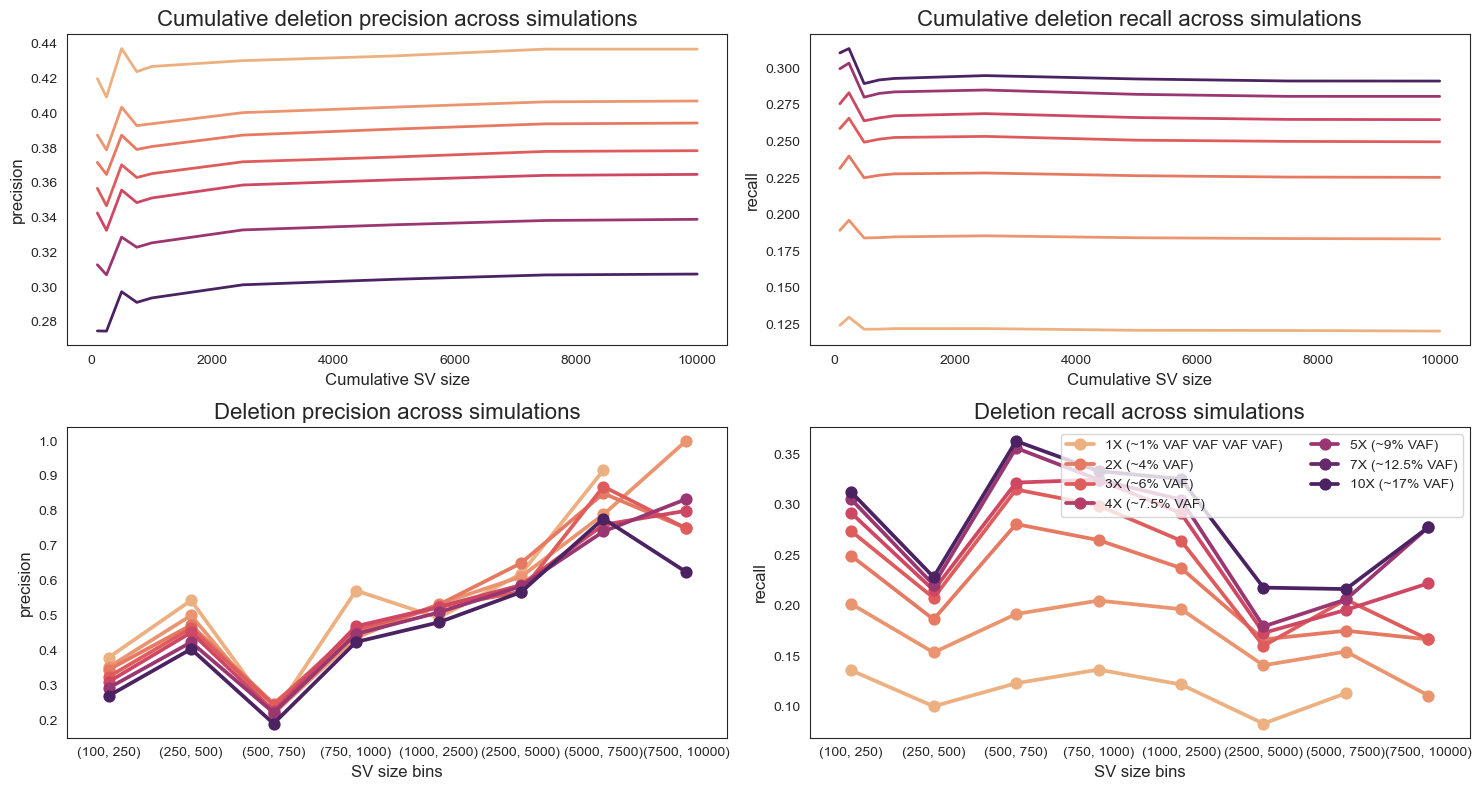

In [464]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for t_ax, svtype, info in zip(axes.flatten()[:2], ['DEL', 'DEL'], ['precision', 'recall']):
    sns.lineplot(cumulative_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = t_ax, x = 'upper_svlen', y = info, hue = 'coverage',
                     palette = sns.color_palette("flare", as_cmap = True), linewidth = 2, legend = None)
    t_ax.set_title("Cumulative deletion {info} across simulations".format(info = info), size = 16)
    t_ax.set_ylabel(info, size = 12)
    t_ax.set_xlabel('Cumulative SV size', size = 12)

for index, b_ax, svtype, info in zip([0,1], axes.flatten()[2:], ['DEL', 'DEL'], ['precision', 'recall']):
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("flare", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'])
    b_ax.set_title("Deletion {info} across simulations".format(info = info), size = 16)
    b_ax.set_ylabel(info, size = 12)
    b_ax.set_xlabel('SV size bins', size = 12)

    # fixes mis-labeled coverage labels: not sure why that happens, it's weird
    h, l = b_ax.get_legend_handles_labels()
    b_ax.legend(handles = h, labels = ['1X (~1% VAF VAF VAF VAF)', '2X (~4% VAF)', '3X (~6% VAF)', '4X (~7.5% VAF)', '5X (~9% VAF)', '7X (~12.5% VAF)', '10X (~17% VAF)'], ncols = 2, loc = 'upper right')

    if index != 1:
        b_ax.get_legend().remove()

plt.tight_layout()

## Combo plot

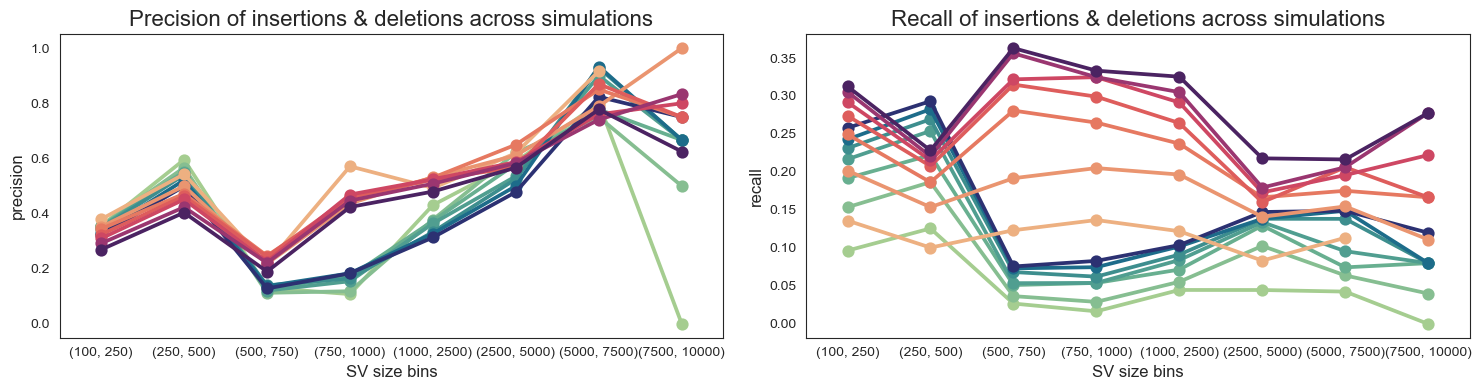

In [339]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,4))

for b_ax, svtype, info in zip(axes.flatten(), ['INS', 'INS'], ['precision', 'recall']):
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("crest", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      legend = None)

for b_ax, svtype, info in zip(axes.flatten(), ['DEL', 'DEL'], ['precision', 'recall']):
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("flare", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      legend = None)
    b_ax.set_title("{info} of insertions & deletions across simulations".format(info = info.capitalize()), size = 16)
    b_ax.set_ylabel(info, size = 12)
    b_ax.set_xlabel('SV size bins', size = 12)

plt.tight_layout()

## With benchmark annotations

In [340]:
# pick 3X coverage just because visuals are HARD

ins_benchmark = bins_df.query("svtype == 'INS' & coverage == 3")[['base cnt', 'TP-comp', 'FP']]
ins_benchmark = ins_benchmark.rename(columns = {'base cnt': 'Benchmark', 'TP-comp': 'Simulation (true pos.)', 'FP': 'Simulation (false pos.)'}).stack().to_frame()
ins_benchmark.index.rename(['coverage', 'svtype', 'bin_range', 'count_type'], inplace = True)
ins_benchmark.rename(columns = {0: 'counts'}, inplace = True)

# pick 3X coverage just because visuals are HARD
del_benchmark = bins_df.query("svtype == 'DEL' & coverage == 3")[['base cnt', 'TP-comp', 'FP']]
del_benchmark = del_benchmark.rename(columns = {'base cnt': 'Benchmark', 'TP-comp': 'Simulation (true pos.)', 'FP': 'Simulation (false pos.)'}).stack().to_frame()
del_benchmark.index.rename(['coverage', 'svtype', 'bin_range', 'count_type'], inplace = True)
del_benchmark.rename(columns = {0: 'counts'}, inplace = True)

### Insertion precision/recall

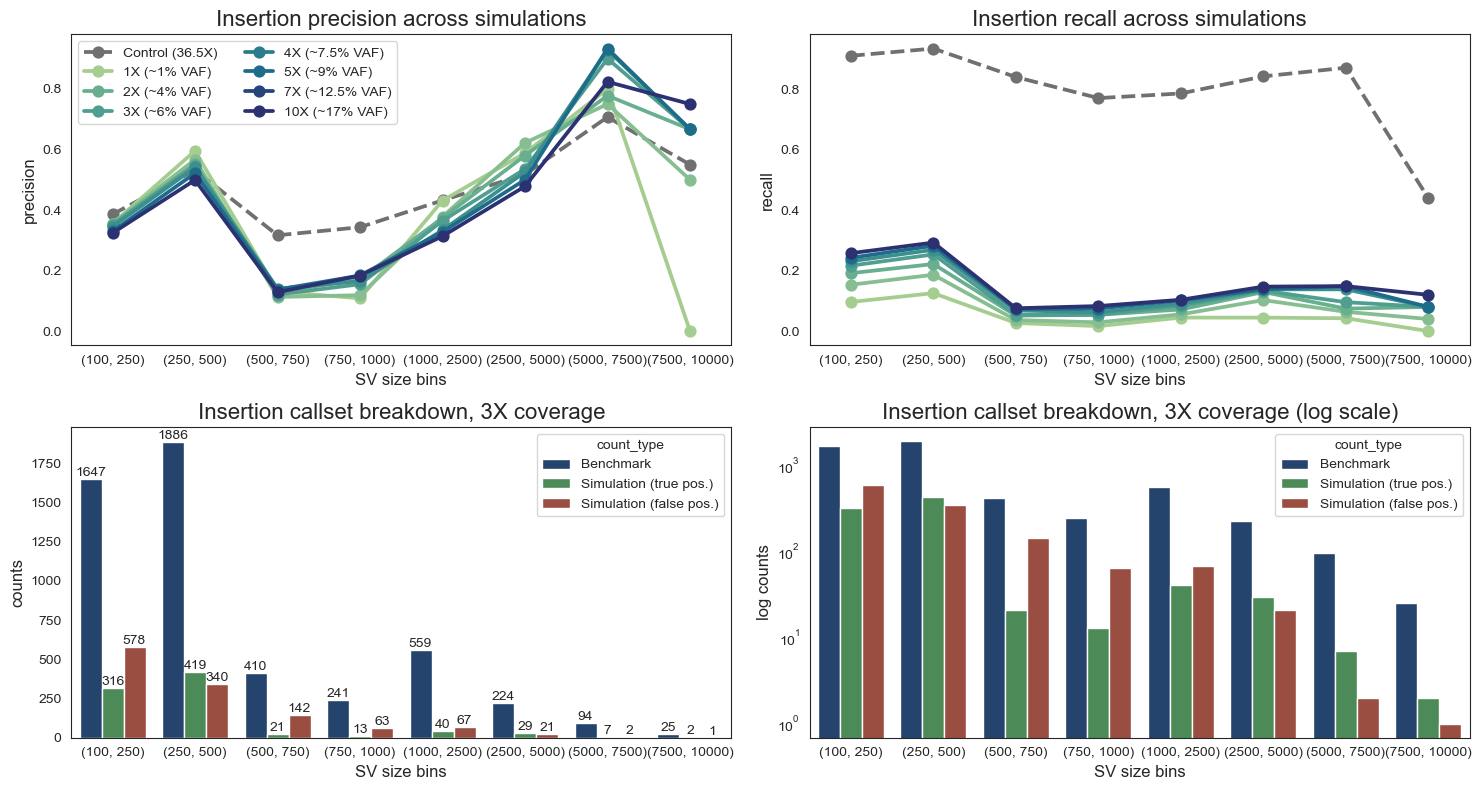

In [465]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for index, b_ax, svtype, info in zip([0,1], axes.flatten()[:2], ['INS', 'INS'], ['precision', 'recall']):
    # control line
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      color = '#707070',
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Control (36.5X)')
    b_ax.lines[0].set_linestyle("--")

    # simulation lines
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("crest", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'])

    b_ax.set_title("Insertion {info} across simulations".format(info = info), size = 16)
    b_ax.set_xlabel("SV size bins", size = 12)
    b_ax.set_ylabel(info, size = 12)
    b_ax.tick_params(axis='x', labelsize = 10)
    
    # fixes mis-labeled coverage labels: not sure why that happens, it's weird
    h, l = b_ax.get_legend_handles_labels()
    b_ax.legend(handles = h, labels = ['Control (36.5X)', '1X (~1% VAF)', '2X (~4% VAF)', '3X (~6% VAF)', '4X (~7.5% VAF)', '5X (~9% VAF)', '7X (~12.5% VAF)', '10X (~17% VAF)'], ncols = 2, loc = 'upper left')
    
    if index != 0:
        b_ax.get_legend().remove()

sns.barplot(ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[2], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[2].set_title("Insertion callset breakdown, 3X coverage", size = 16)
axes.flatten()[2].set_ylabel("counts", size = 12)
axes.flatten()[2].set_xlabel("SV size bins", size = 12)
for bar in axes.flatten()[2].containers:
    axes.flatten()[2].bar_label(bar, fontsize=10)

sns.barplot(ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[3], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[3].set_title("Insertion callset breakdown, 3X coverage (log scale)", size = 16)
axes.flatten()[3].set_yscale("log")
axes.flatten()[3].set_ylabel("log counts", size = 12)
axes.flatten()[3].set_xlabel("SV size bins", size = 12)

plt.tight_layout()

### Deletion precision/recall

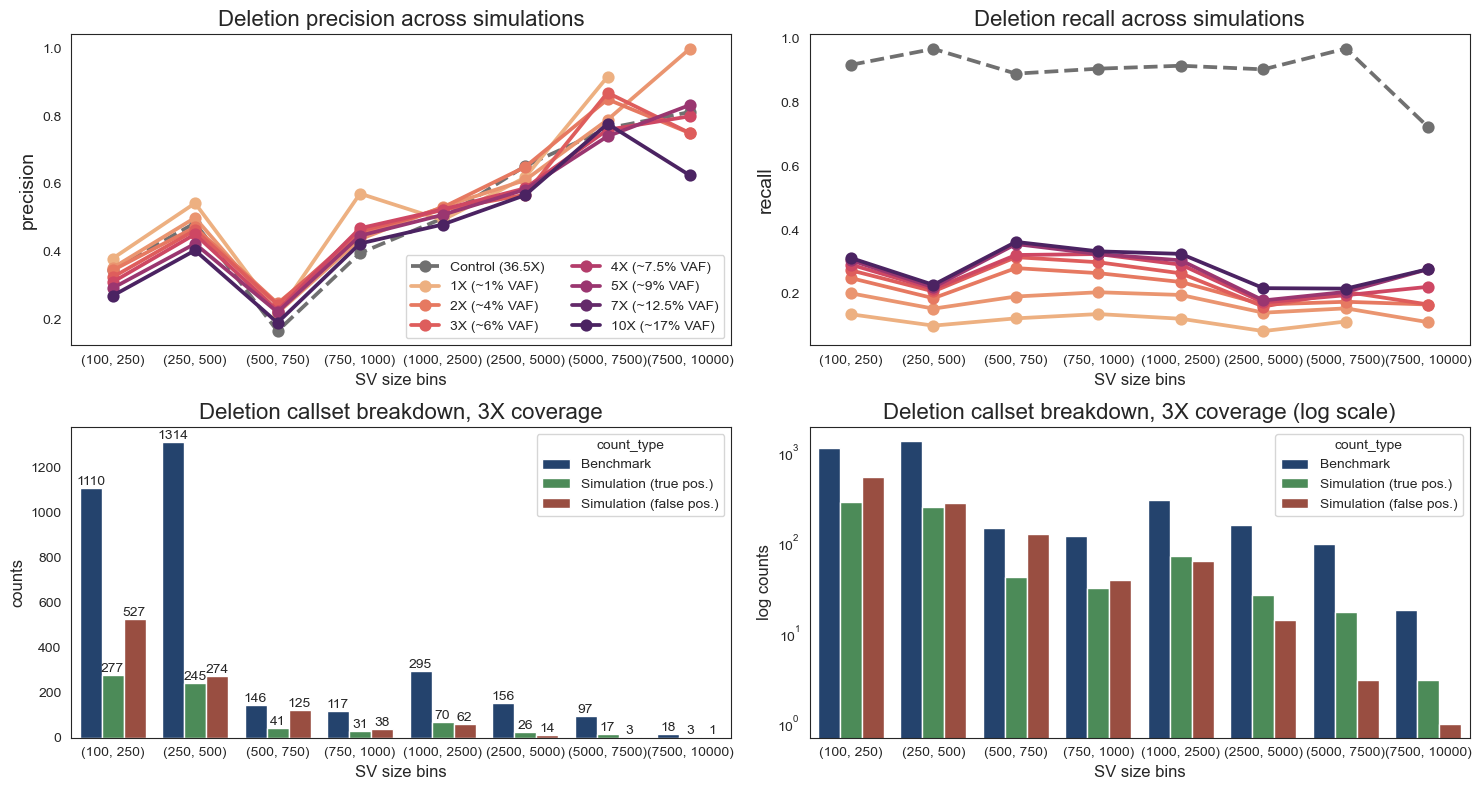

In [466]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for index, b_ax, svtype, info in zip([0,1], axes.flatten()[:2], ['DEL', 'DEL'], ['precision', 'recall']):
    # control line
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      color = '#707070',
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Control (36.5X)')
    b_ax.lines[0].set_linestyle("--")

    # simulation lines
    sns.pointplot(bins_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info, hue = 'coverage', 
                      palette = sns.color_palette("flare", as_cmap = True),
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'])
    b_ax.set_title("Deletion {info} across simulations".format(info = info), size = 16)
    b_ax.set_xlabel("SV size bins", size = 12)
    b_ax.set_ylabel(info, size = 14)
    b_ax.tick_params(axis='x', labelsize = 10)
    
    # fixes mis-labeled coverage labels: not sure why that happens, it's weird
    h, l = b_ax.get_legend_handles_labels()
    b_ax.legend(handles = h, labels = ['Control (36.5X)', '1X (~1% VAF)', '2X (~4% VAF)', '3X (~6% VAF)', '4X (~7.5% VAF)', '5X (~9% VAF)', '7X (~12.5% VAF)', '10X (~17% VAF)'], ncols = 2, loc = 'lower right')
    
    if index != 0:
        b_ax.get_legend().remove()

sns.barplot(del_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[2], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[2].set_title("Deletion callset breakdown, 3X coverage", size = 16)
axes.flatten()[2].set_ylabel("counts", size = 12)
axes.flatten()[2].set_xlabel("SV size bins", size = 12)
for bar in axes.flatten()[2].containers:
    axes.flatten()[2].bar_label(bar, fontsize=10)

sns.barplot(del_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[3], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[3].set_title("Deletion callset breakdown, 3X coverage (log scale)", size = 16)
axes.flatten()[3].set_yscale("log")
axes.flatten()[3].set_ylabel("log counts", size = 12)
axes.flatten()[3].set_xlabel("SV size bins", size = 12)

plt.tight_layout()

### F1 scores (both ins/del)

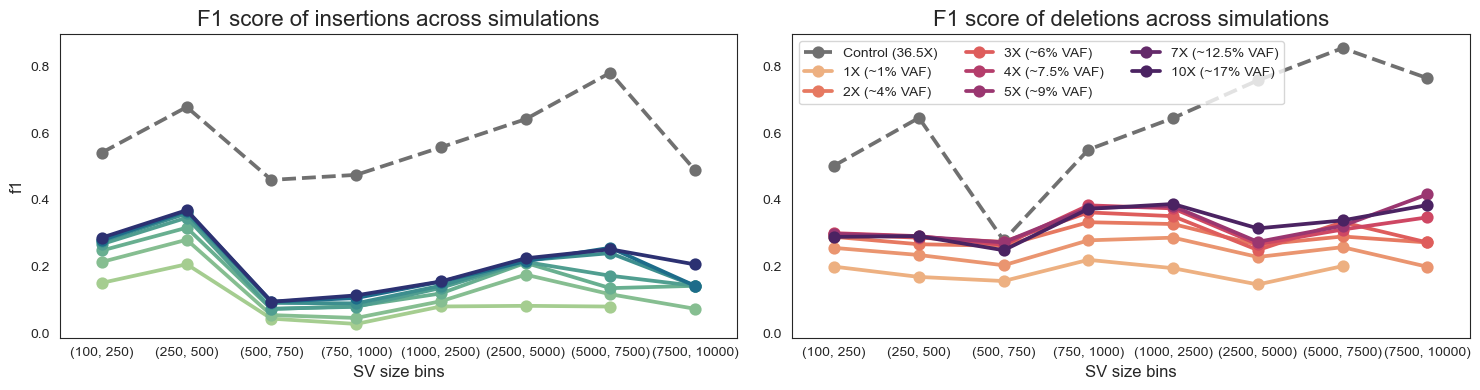

In [467]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,4), sharey = True)


for ax, svtype, info in zip(axes.flatten(), ['INS', 'DEL'], ['f1', 'f1']):
    # control line
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = ax, x = 'bin_range', y = info,
                        color = '#707070',
                        order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                        label = 'Control (36.5X)')
    ax.lines[0].set_linestyle("--")

    ax.set_xlabel("SV size bins", size = 12)
    ax.set_ylabel(info, size = 12)
    ax.tick_params(axis='x', labelsize = 10)

axes.flatten()[0].set_title("F1 score of insertions across simulations", size = 16)
axes.flatten()[1].set_title("F1 score of deletions across simulations", size = 16)

# simulation lines
sns.pointplot(bins_df.query("svtype == 'INS'"), ax = axes[0], x = 'bin_range', y = info, hue = 'coverage', 
                    palette = sns.color_palette("crest", as_cmap = True),
                    order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'])
sns.pointplot(bins_df.query("svtype == 'DEL'"), ax = axes[1], x = 'bin_range', y = info, hue = 'coverage', 
                    palette = sns.color_palette("flare", as_cmap = True),
                    order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'])

for index, ax in zip([0,1], axes.flatten()):
    # fixes mis-labeled coverage labels: not sure why that happens, it's weird
    h, l = ax.get_legend_handles_labels()
    ax.legend(handles = h, labels = ['Control (36.5X)', '1X (~1% VAF)', '2X (~4% VAF)', '3X (~6% VAF)', '4X (~7.5% VAF)', '5X (~9% VAF)', '7X (~12.5% VAF)', '10X (~17% VAF)'], ncols = 3, loc = 'upper left')
    ax.yaxis.set_tick_params(labelleft=True)

    if index != 1:
        ax.get_legend().remove()

plt.tight_layout()

# Control (bins only)

In [343]:
def create_control_labels(svtype, upper, lower = None):
    labels = []
    if lower == None:
        for sv, upper_svlen in itertools.product(coverage, svtype, upper):
            labels.append([cov, sv, upper_svlen])
    else:
        for sv in svtype:
            for bin_range in zip(lower, upper):
                labels.append([sv, bin_range])
    # always in the order of svtype, upper OR svtype, bin_range
    return labels

def control_bins_json(base_path, labels, return_full = False):
    json_paths = [base_path.format(svtype = label[0], lower = label[1][0], upper = label[1][1]) for label in labels]
    temp = []

    for path, label in zip(json_paths, labels):
            report = pd.read_json(path).loc['size']
            labels = pd.Series(label, index = ['svtype', 'bin_range'])
            temp.append(pd.concat([report, labels]))
    if return_full:
        bindf = pd.DataFrame(temp)
        bindf['bin_range'] = bindf['bin_range'].astype('str').str.replace('()', '', regex = True).astype('category')
        return bindf.set_index(['svtype', 'bin_range'])
    else:
        bindf = pd.DataFrame(temp)
        bindf['bin_range'] = bindf['bin_range'].astype('str').str.replace('()', '', regex = True).astype('category')
        return bindf.set_index(['svtype', 'bin_range'])[['precision', 'recall']]

control_labels = create_control_labels(svtype = ['INS', 'DEL'], lower = [100, 250, 500, 750, 1000, 2500, 5000, 7500], upper = [250, 500, 750, 1000, 2500, 5000, 7500, 10000])
control_df = control_bins_json('output/mapping/hg38/simulations/control/HG002/truvari/{svtype}/bins/{lower}_{upper}/summary.json', control_labels, return_full = True)
control_df.sort_index(inplace=True)

In [392]:
# pick 3X coverage just because visuals are HARD

ctrl_all_benchmark = control_df[['base cnt', 'TP-comp', 'FP', 'f1']]
ctrl_all_benchmark = ctrl_all_benchmark.rename(columns = {'base cnt': 'Benchmark', 'TP-comp': 'Control (true pos.)', 'FP': 'Control (false pos.)'}).stack().to_frame()
ctrl_all_benchmark.index.rename(['svtype', 'bin_range', 'count_type'], inplace = True)
ctrl_all_benchmark.rename(columns = {0: 'counts'}, inplace = True)

ctrl_ins_benchmark = control_df.query("svtype == 'INS'")[['base cnt', 'TP-comp', 'FP', 'f1']]
ctrl_ins_benchmark = ctrl_ins_benchmark.rename(columns = {'base cnt': 'Benchmark', 'TP-comp': 'Control (true pos.)', 'FP': 'Control (false pos.)'}).stack().to_frame()
ctrl_ins_benchmark.index.rename(['svtype', 'bin_range', 'count_type'], inplace = True)
ctrl_ins_benchmark.rename(columns = {0: 'counts'}, inplace = True)

# pick 3X coverage just because visuals are HARD
ctrl_del_benchmark = control_df.query("svtype == 'DEL'")[['base cnt', 'TP-comp', 'FP', 'f1']]
ctrl_del_benchmark = ctrl_del_benchmark.rename(columns = {'base cnt': 'Benchmark', 'TP-comp': 'Control (true pos.)', 'FP': 'Control (false pos.)'}).stack().to_frame()
ctrl_del_benchmark.index.rename(['svtype', 'bin_range', 'count_type'], inplace = True)
ctrl_del_benchmark.rename(columns = {0: 'counts'}, inplace = True)

### SV size breakdown

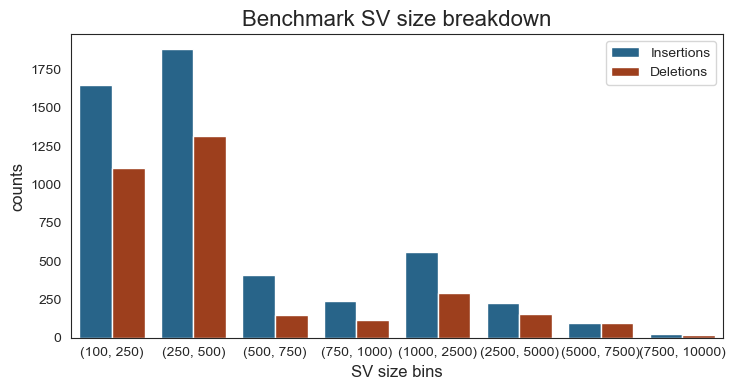

In [375]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (7.5,4))

sns.barplot(ctrl_all_benchmark.query("count_type == 'Benchmark'"), x = 'bin_range', y = 'counts', hue = 'svtype',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            hue_order = ['INS', 'DEL'],
            ax = ax, palette = ['#186899', '#b33507'])
h, l = ax.get_legend_handles_labels()
ax.legend(handles = h, labels = ['Insertions', 'Deletions'])
ax.set_title("Benchmark SV size breakdown", size = 16)
ax.set_ylabel("counts", size = 12)
ax.set_xlabel("SV size bins", size = 12)
plt.tight_layout()

## Ins & del precision/recall

In [424]:
control_df.query("svtype == 'INS'")

TP-base  TP-comp    FP   FN  precision    recall  \
svtype bin_range                                                         
INS    (100, 250)        1502     1502  2394  145   0.385524  0.911961   
       (1000, 2500)       440      440   579  119   0.431796  0.787120   
       (250, 500)        1765     1765  1554  121   0.531787  0.935843   
       (2500, 5000)       189      189   176   35   0.517808  0.843750   
       (500, 750)         345      345   745   65   0.316514  0.841463   
       (5000, 7500)        82       82    34   12   0.706897  0.872340   
       (750, 1000)        186      186   356   55   0.343173  0.771784   
       (7500, 10000)       11       11     9   14   0.550000  0.440000   

                            f1  base cnt  comp cnt  TP-comp_TP-gt  \
svtype bin_range                                                    
INS    (100, 250)     0.541945      1647      3896           1429   
       (1000, 2500)   0.557668       559      1019            365   
       (250, 500)     0.678194      1886      3319           1720   
       (2500, 5000)   0.641766       224       365            124   
       (500, 750)     0.460000       410      1090            330   
       (5000, 7500)   0.780952        94       116             50   
       (750, 1000)    0.475096       241       542            174   
       (7500, 10000)  0.488889        25        20              8   

                      TP-comp_FP-gt  TP-base_TP-gt  TP-base_FP-gt  \
svtype bin_range                                                    
INS    (100, 250)                73           1429             73   
       (1000, 2500)              75            365             75   
       (250, 500)                45           1720             45   
       (2500, 5000)              65            124             65   
       (500, 750)                15            330             15   
       (5000, 7500)              32             50             32   
       (750, 1000)               12            174             12   
       (7500, 10000)              3              8              3   

                      gt_concordance  gt_matrix  \
svtype bin_range                                  
INS    (100, 250)           0.951398        NaN   
       (1000, 2500)         0.829545        NaN   
       (250, 500)           0.974504        NaN   
       (2500, 5000)         0.656085        NaN   
       (500, 750)           0.956522        NaN   
       (5000, 7500)         0.609756        NaN   
       (750, 1000)          0.935484        NaN   
       (7500, 10000)        0.727273        NaN   

                                                               weighted  
svtype bin_range                                                         
INS    (100, 250)     {'TP': 1507.7300998270512, 'FP': 2389.00720015...  
       (1000, 2500)   {'TP': 454.8058011829853, 'FP': 564.1941988170...  
       (250, 500)     {'TP': 1768.5402015447617, 'FP': 1550.45979845...  
       (2500, 5000)   {'TP': 191.8637000322342, 'FP': 173.1362999677...  
       (500, 750)     {'TP': 364.430599629879, 'FP': 726.36640036106...  
       (5000, 7500)   {'TP': 83.23180013895035, 'FP': 32.76819986104...  
       (750, 1000)    {'TP': 196.62550008296967, 'FP': 345.374499917...  
       (7500, 10000)  {'TP': 11.75220000743866, 'FP': 8.247799992561...

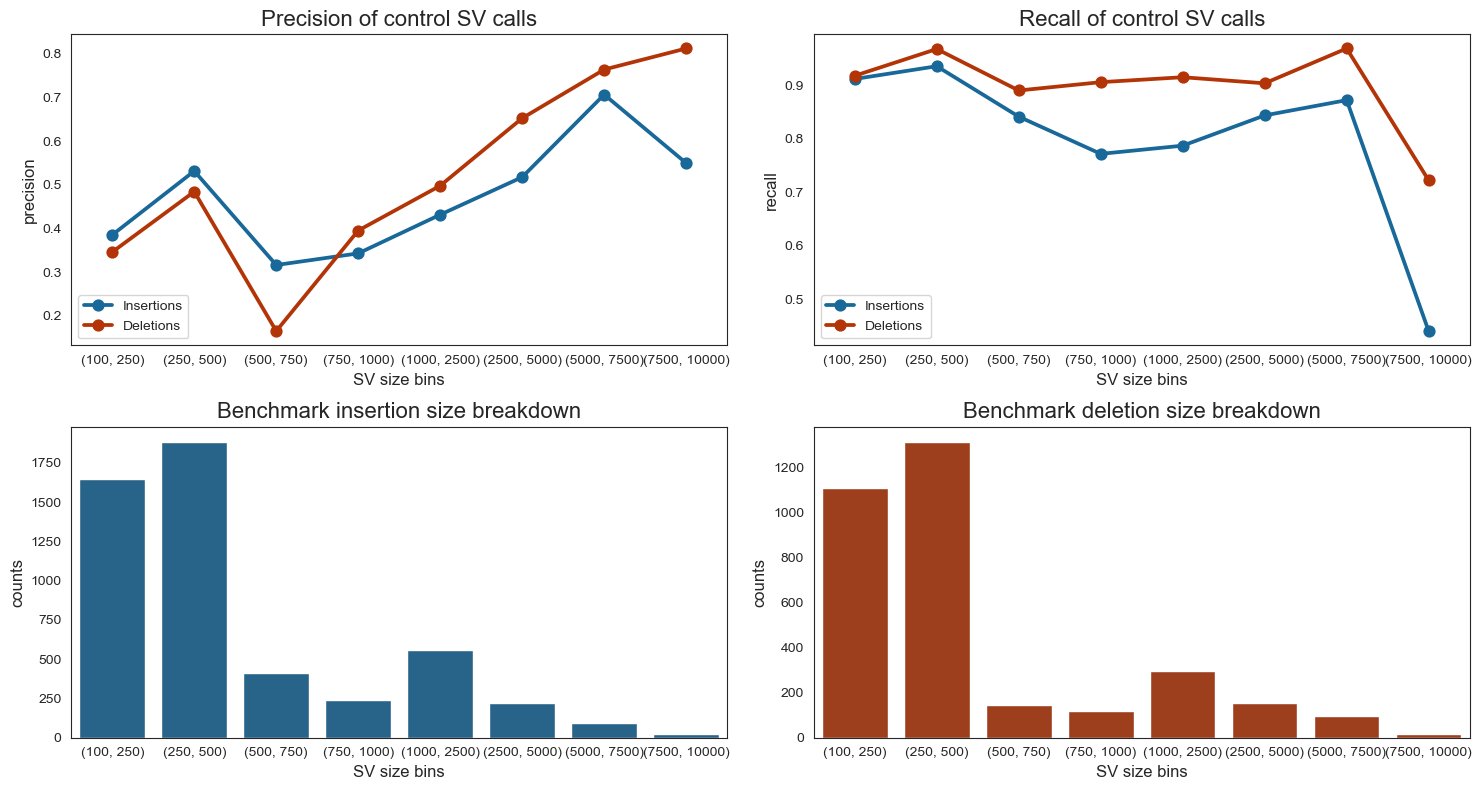

In [429]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))


for b_ax, svtype, info in zip(axes.flatten()[:2], ['INS', 'INS'], ['precision', 'recall']):
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      color = '#186899',
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Insertions')
    b_ax.legend(loc = 'lower right')

for b_ax, svtype, info in zip(axes.flatten()[:2], ['DEL', 'DEL'], ['precision', 'recall']):
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      color = '#b33507',
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Deletions')
    b_ax.set_title("{info} of control SV calls".format(info = info.capitalize()), size = 16)
    b_ax.set_ylabel(info, size = 12)
    b_ax.set_xlabel('SV size bins', size = 12)
    b_ax.legend(loc = 'lower left')

sns.barplot(ctrl_ins_benchmark.query("count_type == 'Benchmark'"), x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[2], palette = ['#186899'], legend = None)
axes.flatten()[2].set_title("Benchmark insertion size breakdown", size = 16)
axes.flatten()[2].set_ylabel("counts", size = 12)
axes.flatten()[2].set_xlabel("SV size bins", size = 12)
# for bar in axes.flatten()[2].containers:
#     axes.flatten()[2].bar_label(bar, fontsize=10)

sns.barplot(ctrl_del_benchmark.query("count_type == 'Benchmark'"), x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[3], palette = ['#b33507'], legend = None)
axes.flatten()[3].set_title("Benchmark deletion size breakdown", size = 16)
axes.flatten()[3].set_ylabel("counts", size = 12)
axes.flatten()[3].set_xlabel("SV size bins", size = 12)

plt.tight_layout()

### F1 scores + precision comparison (both ins/del)

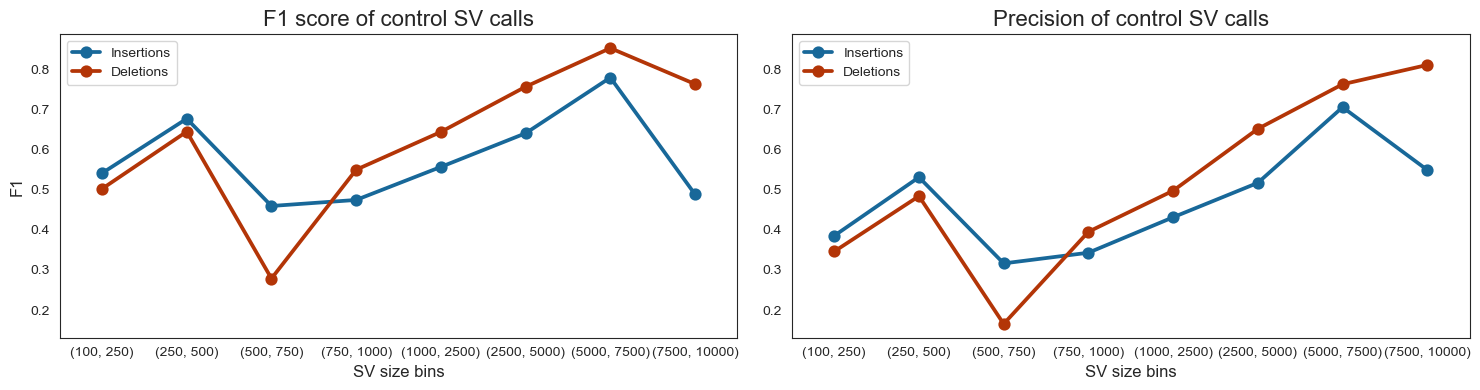

In [441]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,4), sharey = True)

sns.pointplot(ctrl_all_benchmark.query("count_type == 'f1'"), x = 'bin_range', y = 'counts', hue = 'svtype',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            hue_order = ['INS', 'DEL'],
            ax = ax[0], palette = ['#186899', '#b33507'])

h, l = ax[0].get_legend_handles_labels()
ax[0].legend(handles = h, labels = ['Insertions', 'Deletions'])
ax[0].set_title("F1 score of control SV calls", size = 16)
ax[0].set_ylabel("F1", size = 12)
ax[0].set_xlabel("SV size bins", size = 12)

sns.pointplot(control_df.query("svtype == 'INS'"), ax = ax[1], x = 'bin_range', y = 'precision',
                    color = '#186899',
                    order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                    label = 'Insertions')

sns.pointplot(control_df.query("svtype == 'DEL'"), ax = ax[1], x = 'bin_range', y = 'precision',
                    color = '#b33507',
                    order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                    label = 'Deletions')

ax[1].set_title("Precision of control SV calls", size = 16)
ax[1].set_ylabel("precision", size = 12)
ax[1].set_xlabel("SV size bins", size = 12)
ax[1].yaxis.set_tick_params(labelleft=True)

plt.tight_layout()

## With benchmark annotations

### Insertion precision/recall

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_84639/3270618880.py:18: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(ctrl_ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_84639/3270618880.py:26: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(ctrl_ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',


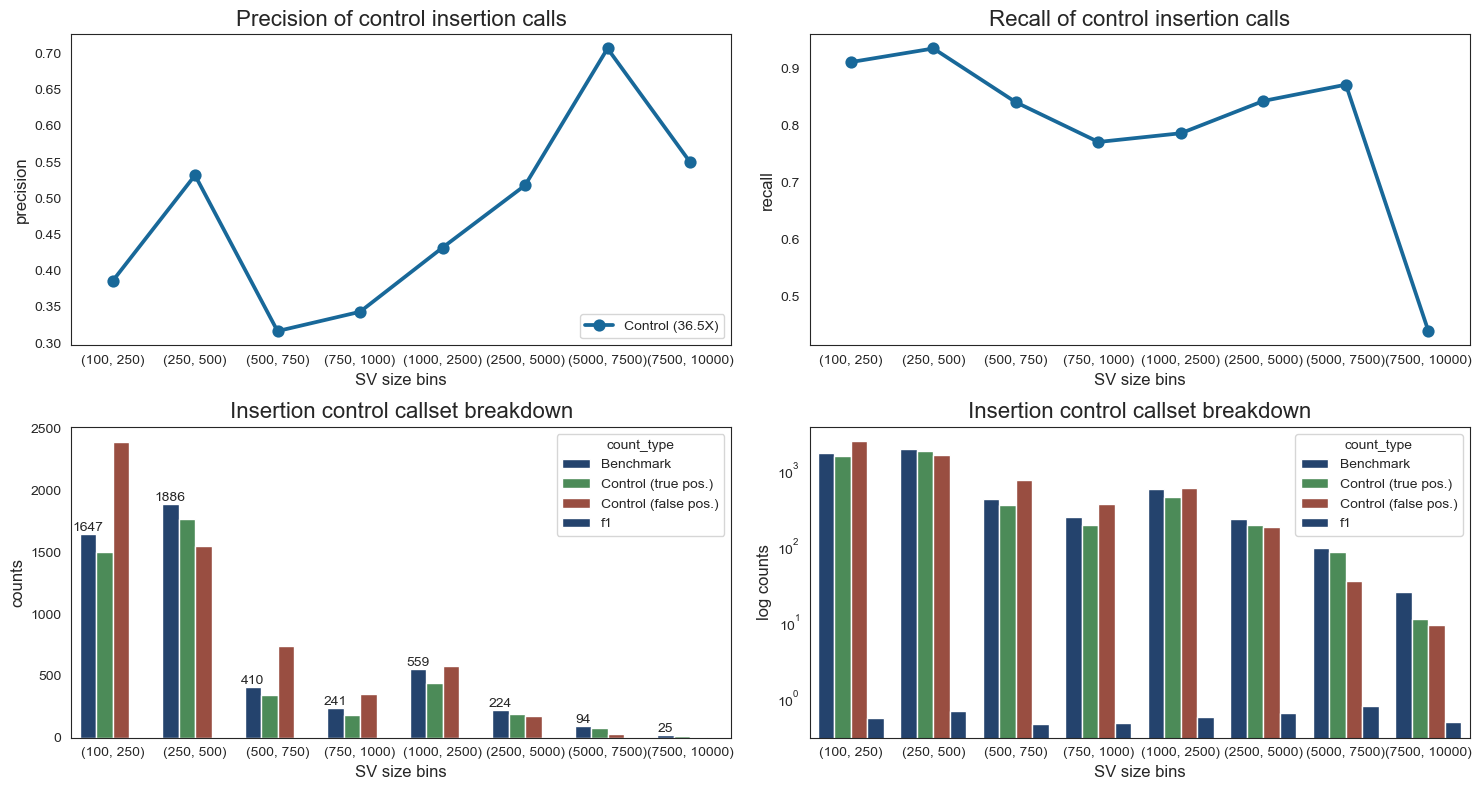

In [436]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for index, b_ax, svtype, info in zip([0,1], axes.flatten()[:2], ['INS', 'INS'], ['precision', 'recall']):
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Control (36.5X)',
                      color = '#186899')
    b_ax.set_title("{info} of control insertion calls".format(info = info.capitalize()), size = 16)
    b_ax.set_xlabel("SV size bins", size = 12)
    b_ax.set_ylabel(info, size = 12)
    b_ax.tick_params(axis='x', labelsize = 10)
    
    b_ax.legend(loc = 'lower right')
    
    if index != 0:
        b_ax.get_legend().remove()

sns.barplot(ctrl_ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[2], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[2].set_title("Insertion control callset breakdown", size = 16)
axes.flatten()[2].set_ylabel("counts", size = 12)
axes.flatten()[2].set_xlabel("SV size bins", size = 12)
axes.flatten()[2].bar_label(axes.flatten()[2].containers[0], fontsize=10)

sns.barplot(ctrl_ins_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[3], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[3].set_title("Insertion control callset breakdown", size = 16)
axes.flatten()[3].set_yscale("log")
axes.flatten()[3].set_ylabel("log counts", size = 12)
axes.flatten()[3].set_xlabel("SV size bins", size = 12)

plt.tight_layout()

### Deletion precision/recall

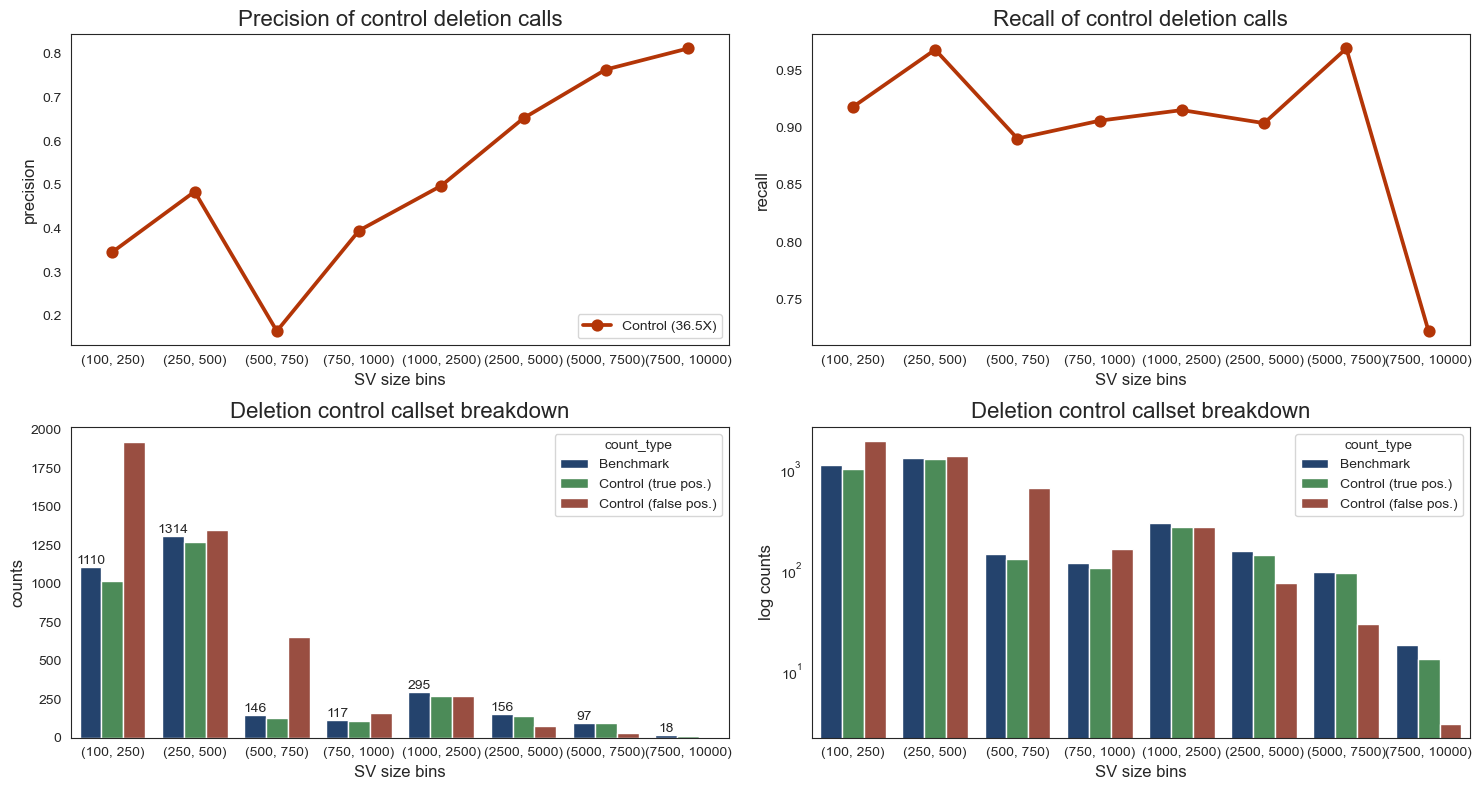

In [356]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15,8))

for index, b_ax, svtype, info in zip([0,1], axes.flatten()[:2], ['DEL', 'DEL'], ['precision', 'recall']):
    sns.pointplot(control_df.query("svtype == '{svtype}'".format(svtype=svtype)), ax = b_ax, x = 'bin_range', y = info,
                      order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
                      label = 'Control (36.5X)',
                      palette = ['#b33507'])
    b_ax.set_title("{info} of control deletion calls".format(info = info.capitalize()), size = 16)
    b_ax.set_xlabel("SV size bins", size = 12)
    b_ax.set_ylabel(info, size = 12)
    b_ax.tick_params(axis='x', labelsize = 10)
    
    b_ax.legend(loc = 'lower right')
    
    if index != 0:
        b_ax.get_legend().remove()

sns.barplot(ctrl_del_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[2], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[2].set_title("Deletion control callset breakdown", size = 16)
axes.flatten()[2].set_ylabel("counts", size = 12)
axes.flatten()[2].set_xlabel("SV size bins", size = 12)
axes.flatten()[2].bar_label(axes.flatten()[2].containers[0], fontsize=10)

sns.barplot(ctrl_del_benchmark, x = 'bin_range', y = 'counts', hue = 'count_type',
            order = ['(100, 250)', '(250, 500)', '(500, 750)', '(750, 1000)', '(1000, 2500)', '(2500, 5000)', '(5000, 7500)', '(7500, 10000)'],
            ax = axes.flatten()[3], palette = ['#184179', '#419552', '#a84432'])
axes.flatten()[3].set_title("Deletion control callset breakdown", size = 16)
axes.flatten()[3].set_yscale("log")
axes.flatten()[3].set_ylabel("log counts", size = 12)
axes.flatten()[3].set_xlabel("SV size bins", size = 12)

plt.tight_layout()

In [245]:
# use this to get hex codes
list(map(mpl.colors.rgb2hex, sns.color_palette("crest")[0:5]))

['#7dba91', '#59a590', '#40908e', '#287a8c', '#1c6488']